In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

# Task 1 - NAV trend analysis 

In [32]:
nav = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

In [33]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.merge(fund_master[["amfi_code","scheme_name"]] , on="amfi_code" , how="left")

In [34]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme Name",
    height=700
)


In [35]:
fig.write_image(
    "../reports/charts/nav_trend_analysis.png",
    width=2000,
    height=1000
)

## Insight 
Most equity schemes showed a strong upward trend during 2023, indicating a broad market bull run, while several schemes experienced temporary corrections during 2024.

# Task 2 - AUM growth bar chart 

In [12]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [13]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

In [14]:
aum_year = (
    aum.sort_values("date")
    .groupby(["fund_house", "year"])
    .tail(1)
    )

In [18]:
top_funds = (
    aum_year.groupby("fund_house")
    ["aum_lakh_crore"]
    .max()
    .nlargest(10)
    .index
)

plot_df = aum_year[
    aum_year["fund_house"].isin(top_funds)
]




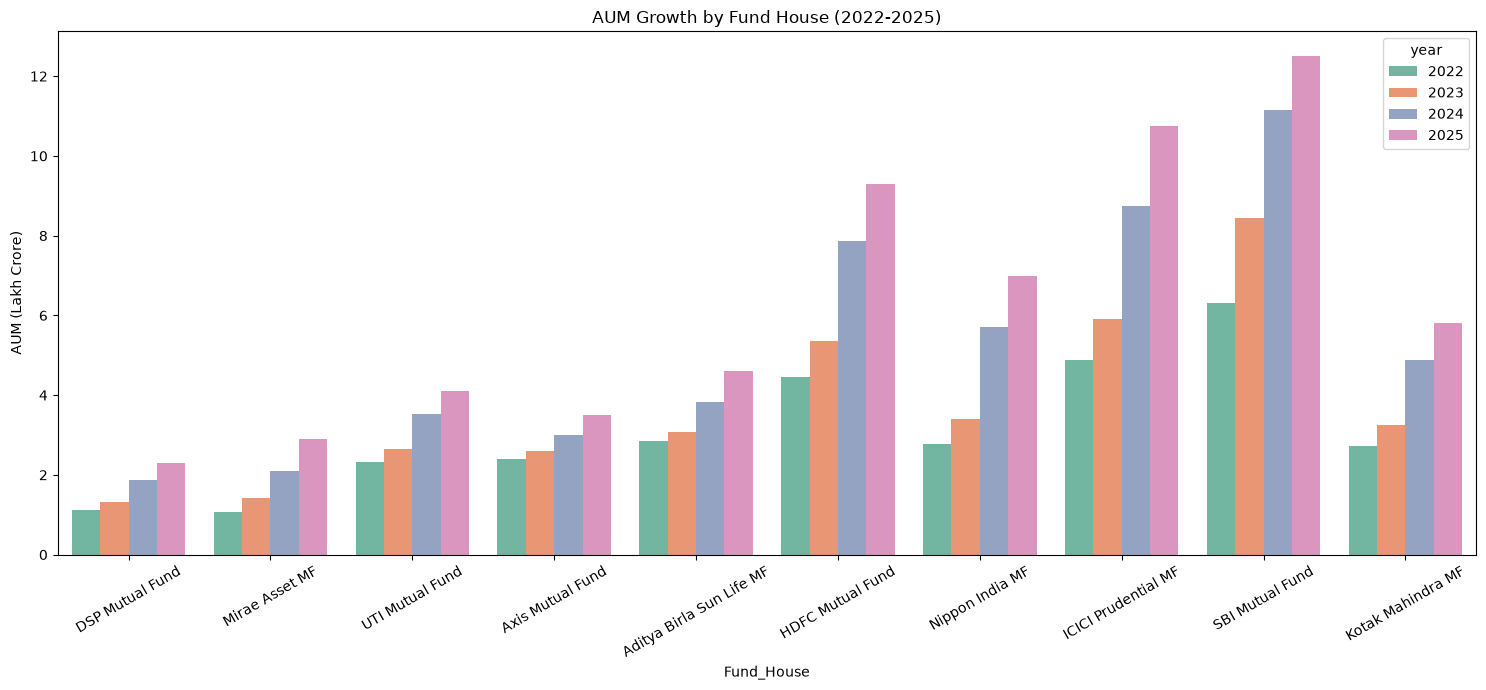

In [17]:
plt.figure(figsize=(15,7))

sns.barplot(
    data = plot_df,
    x = "fund_house",
    y = "aum_lakh_crore",
    hue = "year",
    palette=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]
    )

plt.xticks(rotation = 30)
plt.ylabel("AUM (Lakh Crore)")
plt.xlabel("Fund_House")
plt.title("AUM Growth by Fund House (2022-2025)")

plt.tight_layout()
plt.savefig(
    "../reports/charts/aum_growth.png",
    dpi = 300,
    bbox_inches = "tight"
    
)


In [19]:
sbi_max = aum_year[
    aum_year["fund_house"]=="SBI Mutual Fund"
]["aum_lakh_crore"].max()


print(sbi_max)

12.5


## Insight
SBI Mutual Fund dominated the industry and crossed ₹12.5 lakh crore AUM by 2025, significantly ahead of other fund houses.

# Task 3 - SIP inflow time-series

In [11]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
sip.head()


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [26]:
sip["month"] = pd.to_datetime(sip["month"])
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [27]:
peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [67]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)"
)

fig.add_annotation(
    x=peak["month"].strftime("%Y-%m"),
    y=peak["sip_inflow_crore"],
    text=f"All-Time High In Dec 2025: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()



In [68]:
fig.write_image("../reports/charts/SIP_trend.png")

## Insight
Monthly SIP inflows increased steadily from ₹11,517 Cr in January 2022 to an all-time high of ₹31,002 Cr in December 2025, reflecting strong retail investor participation in mutual funds.

# Task 4 - Category inflow heatmap

In [31]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [34]:
heatmap_data = category.pivot(
    index = "category",
    columns = "month",
    values = "net_inflow_crore"
)

In [35]:
heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


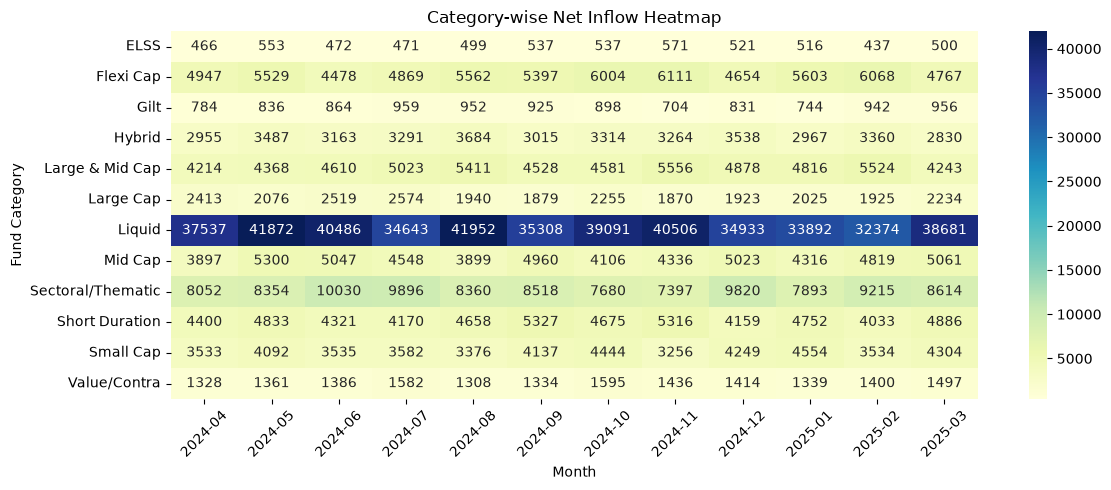

In [65]:
plt.figure(figsize=(12,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    
)

plt.title(
    "Category-wise Net Inflow Heatmap"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
Liquid funds consistently received the highest inflows, often exceeding ₹30,000 crore per month, indicating strong demand for short-term parking of money.

Sectoral/Thematic funds showed strong investor interest, with inflows approaching ₹10,000 crore in several months.

ELSS and Gilt funds attracted comparatively lower inflows than equity and liquid categories.

# Task 5 - Investor demographics

### Age Group Distribution Pie Chart

In [71]:
transactions2 = pd.read_csv(
    "../data/processed/investor_transaction_cleaned.csv"
)

In [76]:
age_counts = (
    transactions2["age_group"]
    .value_counts()
)

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

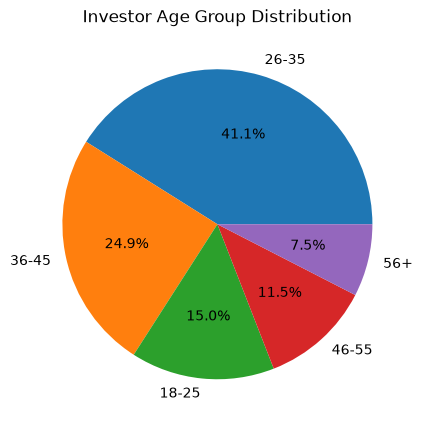

In [80]:
plt.figure(figsize=(5,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Group Distribution"
)

plt.savefig(
    "../reports/charts/age_group_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SIP Amount Box Plot by Age Group

In [81]:
transactions2.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [82]:
sip = transactions2[
    transactions2["transaction_type"] == "SIP"
]

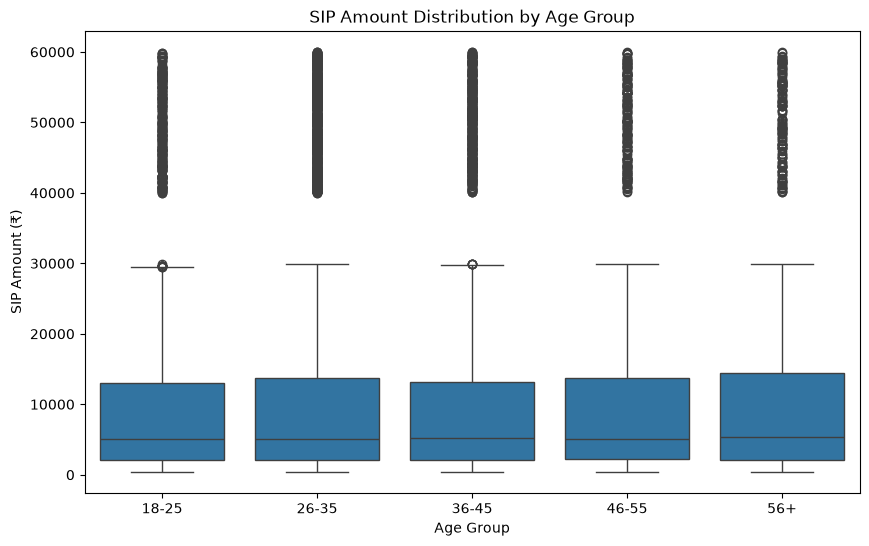

In [87]:
order = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56+"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip,
    x="age_group",
    y="amount_inr",
    order = order
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig(
    "../reports/charts/sip_boxplot_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Gender split

In [88]:
gender_counts = (
    transactions2["gender"]
    .value_counts()
)

gender_counts

gender
Male      21809
Female    10969
Name: count, dtype: int64

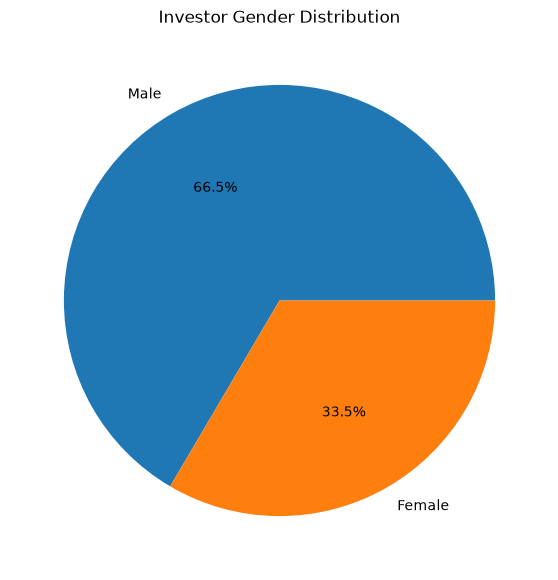

In [93]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Gender Distribution"
)

plt.savefig(
    "../reports/charts/gender_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight

The 26–35 age group contributes the highest number of investors, indicating strong participation from young professionals.

The SIP box plot shows significant variation in investment amounts across age groups, with some investors contributing substantially higher SIP amounts.

The investor base is relatively balanced between male and female investors, showing broad participation across genders.

# Task 6 - Geographic distribution 

### SIP Amount by state

In [97]:
sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [98]:
state_sip = (
    sip.groupby("state")
       ["amount_inr"]
       .sum()
       .sort_values(ascending=False)
       .reset_index()
)

state_sip

,state,amount_inr
0,Madhya Pradesh,20682243
1,Punjab,20140064
2,Telangana,18620216
3,Tamil Nadu,18404368
4,Gujarat,18378904
5,Haryana,18176696
6,Karnataka,17696903
7,Uttar Pradesh,17534858
8,West Bengal,17495769
9,Delhi,17113608


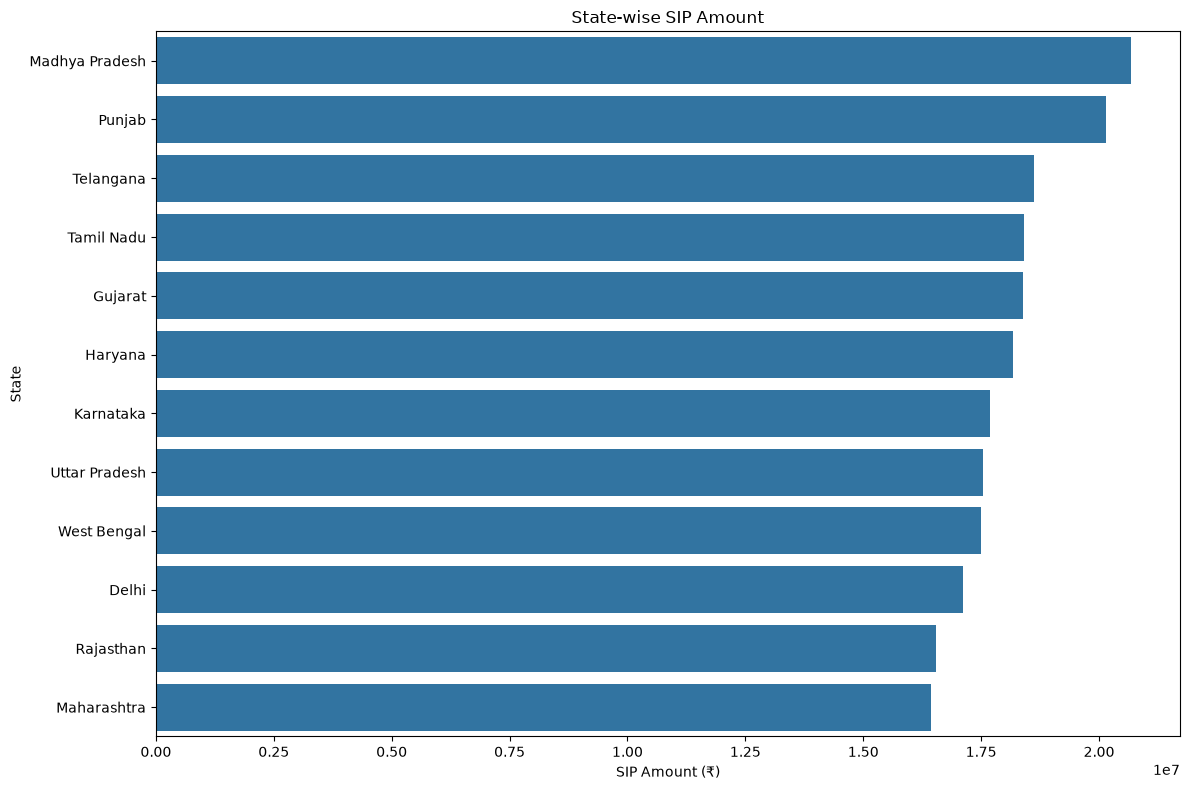

In [100]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title(
    "State-wise SIP Amount"
)

plt.xlabel("SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.savefig(
    "../reports/charts/state_sip_amount.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### T30 vs B30 city tier pie chart

In [101]:
transactions2.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [102]:
transactions2[["city","city_tier"]]

,city,city_tier
0,Hyderabad,T30
1,Amritsar,B30
2,Faridabad,B30
3,Mumbai,T30
4,Noida,T30
...,...,...
32773,Indore,T30
32774,Kanpur,B30
32775,Jaipur,T30
32776,Kolkata,T30


In [103]:
city_counts = (
    transactions2["city_tier"]
    .value_counts()
)

city_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

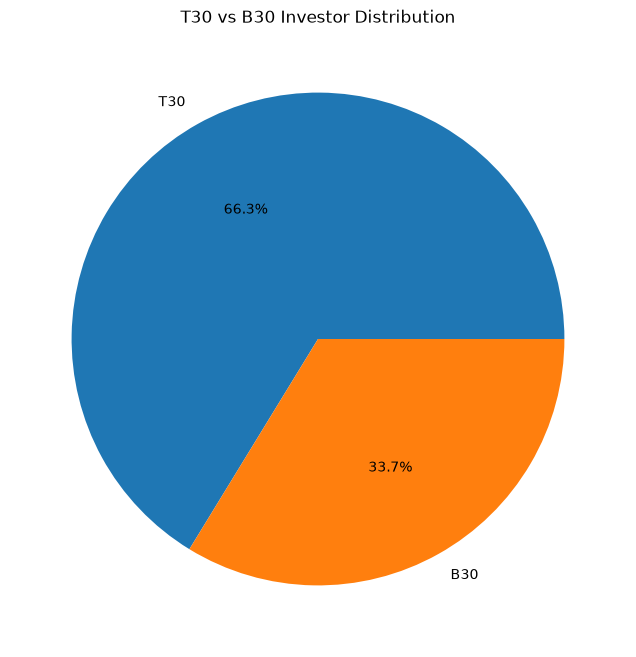

In [106]:
plt.figure(figsize=(8,8))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.savefig(
    "../reports/charts/t30_b30_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
Maharashtra and Karnataka contribute the highest SIP amounts, indicating strong mutual fund participation in major economic states.

A significant proportion of investors come from B30 cities, showing that mutual fund adoption is spreading beyond metropolitan areas.

# Task 7 - Folio count growth 

In [3]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [4]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [5]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

In [114]:
folio

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48
5,2023-04-01,15.54,10.88,2.18,0.93,1.55
6,2023-07-01,16.28,11.40,2.28,0.98,1.63
7,2023-10-01,16.72,11.70,2.34,1.00,1.67
8,2024-01-01,17.78,12.45,2.49,1.07,1.78
9,2024-04-01,18.85,13.20,2.64,1.13,1.89


In [10]:
first_row = folio.iloc[0]
last_row = folio.iloc[-1]

first_row

month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object

In [11]:
milestone = folio[
    folio["total_folios_crore"] >= 20
].iloc[0]

In [14]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Mutual Fund Industry Folio Growth"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)"
)

fig.add_annotation(
    x=first_row["month"].strftime("%Y-%m"),
    y=first_row["total_folios_crore"],
    text="13.26 Cr",
    showarrow=True
)

fig.add_annotation(
    x=last_row["month"].strftime("%Y-%m"),
    y=last_row["total_folios_crore"],
    text="26.12 Cr",
    showarrow=True
)

fig.add_annotation(
    x = milestone["month"].strftime("%Y-%m"),
    y = milestone["total_folios_crore"],
    text = "Crossed 20 Cr folios",
    showarrow = True,
    arrowhead = 2
)

fig.show()

In [15]:
fig.write_image(
    "../reports/charts/folio_growth.png"
)

## Insight
Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting rapid growth in retail participation.

The industry crossed the 20 crore folio milestone in October 2024, indicating accelerating adoption of mutual funds in India.

# Task 8 - NAV return correlation matrix 

In [29]:
nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

In [31]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

In [32]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [36]:
nav_history["amfi_code"].nunique()

40

In [39]:
top10_funds = (
    nav_history["amfi_code"]
    .unique()[:10]
)

top10_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [44]:
nav10 = nav_history[
    nav_history["amfi_code"].isin(top10_funds)
    ]



In [45]:
nav_pivot = nav10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [46]:
nav_pivot

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585
...,...,...,...,...,...,...,...,...,...,...
2026-05-25,599.9335,31.9938,341.0618,767.9581,54.3271,409.3925,181.9025,125.4990,363.3097,108.9319
2026-05-26,596.4426,31.9646,347.6301,762.9328,53.4341,409.4504,182.9999,122.9135,375.0758,109.7152
2026-05-27,590.8555,31.9203,353.8026,766.2056,53.7534,409.7188,183.3905,123.1859,377.1098,110.2646


In [47]:
returns = nav_pivot.pct_change()

In [48]:
returns

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793
...,...,...,...,...,...,...,...,...,...,...
2026-05-25,-0.004227,0.000141,-0.017480,-0.015349,0.027459,0.000363,0.001133,0.016734,0.010121,0.008220
2026-05-26,-0.005819,-0.000913,0.019258,-0.006544,-0.016437,0.000141,0.006033,-0.020602,0.032386,0.007191
2026-05-27,-0.009367,-0.001386,0.017756,0.004290,0.005976,0.000656,0.002134,0.002216,0.005423,0.005008


In [49]:
corr_matrix = returns.corr()

In [50]:
corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


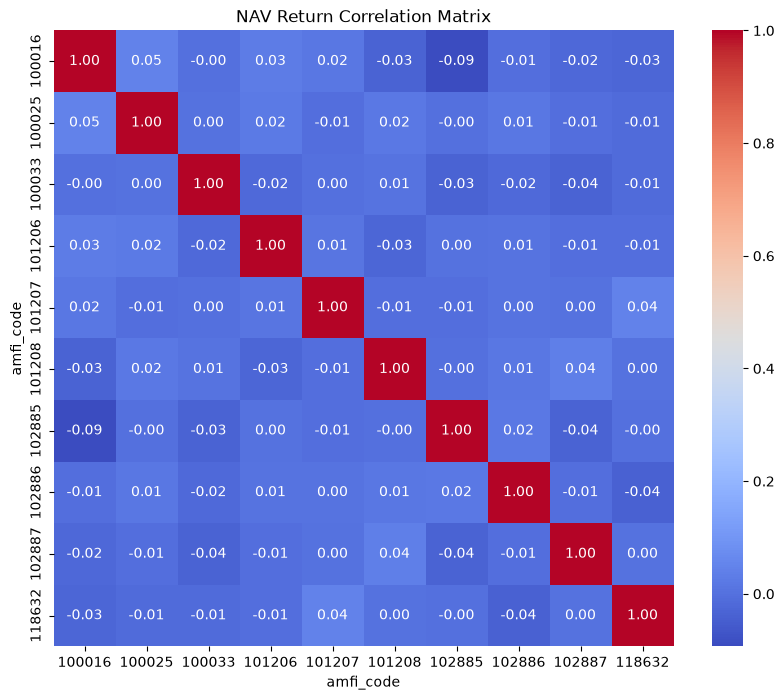

In [52]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.savefig(
    "../reports/charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
Most equity mutual funds exhibit strong positive correlations, indicating that they move in similar directions during market rallies and corrections.

No significant negative correlations were observed, suggesting limited diversification benefits among the selected equity funds.

# Task 9 - Sector Allocation Donut Chart

In [54]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [56]:
sector_weights = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(
        ascending= False
    )
)

In [64]:
sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

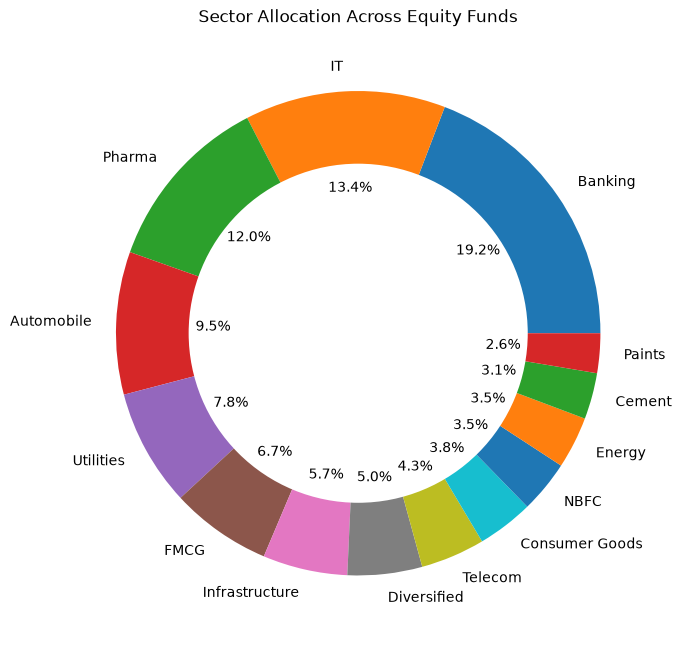

In [66]:
plt.figure(figsize=(7,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Insight
Banking and Financial sectors account for the largest share of portfolio allocation across equity mutual funds.

Sector diversification is evident, with allocations spread across Pharma, Utilities, IT, and Consumer sectors.

The concentration in a few sectors indicates that overall fund performance may be significantly influenced by sector-specific trends.